## LAES optimisation

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0              # Roof heat ingress / W
T_air = 18.08 + 273.15  # Temperature of the environment K

V_tank = 4831 # Tank volume / m^3

a   = 0.5
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 8.72e-2 # W/m2/K
U_V = 8.72e-2 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95

# Specify tank operating pressure
P = 101325*3 # Pa

# Set fixed bottom heat ingress
# q_b_fixed = 100/(np.pi*((8**2)/4))
q_b_fixed = None

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# # Initialise cryogen
cryogen = Cryogen(name = "nitrogen")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))

The initial evaporation rate of nitrogen is 440.2 kg/h
q_b used:  None  q_b free:  17.716951564175947
Q_b used:  7415.327111292465  Q_b free:  7415.327111292465


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of nitrogen is 440.2 kg/h
Transient period = 50680.893 s 
Simulation time: 15 h
BOR = 0.305 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 12 hours
evap_time = 3600 * 12

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 1200

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

optimal Aspect Ratio: [0.55862499 0.54821458 0.53820457 0.52859496 0.51928565 0.51037674
 0.50206843]
optimal Thermal Aspect Ratio: [0.66931659 0.66878994 0.66828899 0.66782194 0.66735427 0.66693557
 0.66666288]
optimal BOR: [0.05349305 0.01353142 0.00782202 0.00553786 0.00430761 0.00353837
 0.00301132]


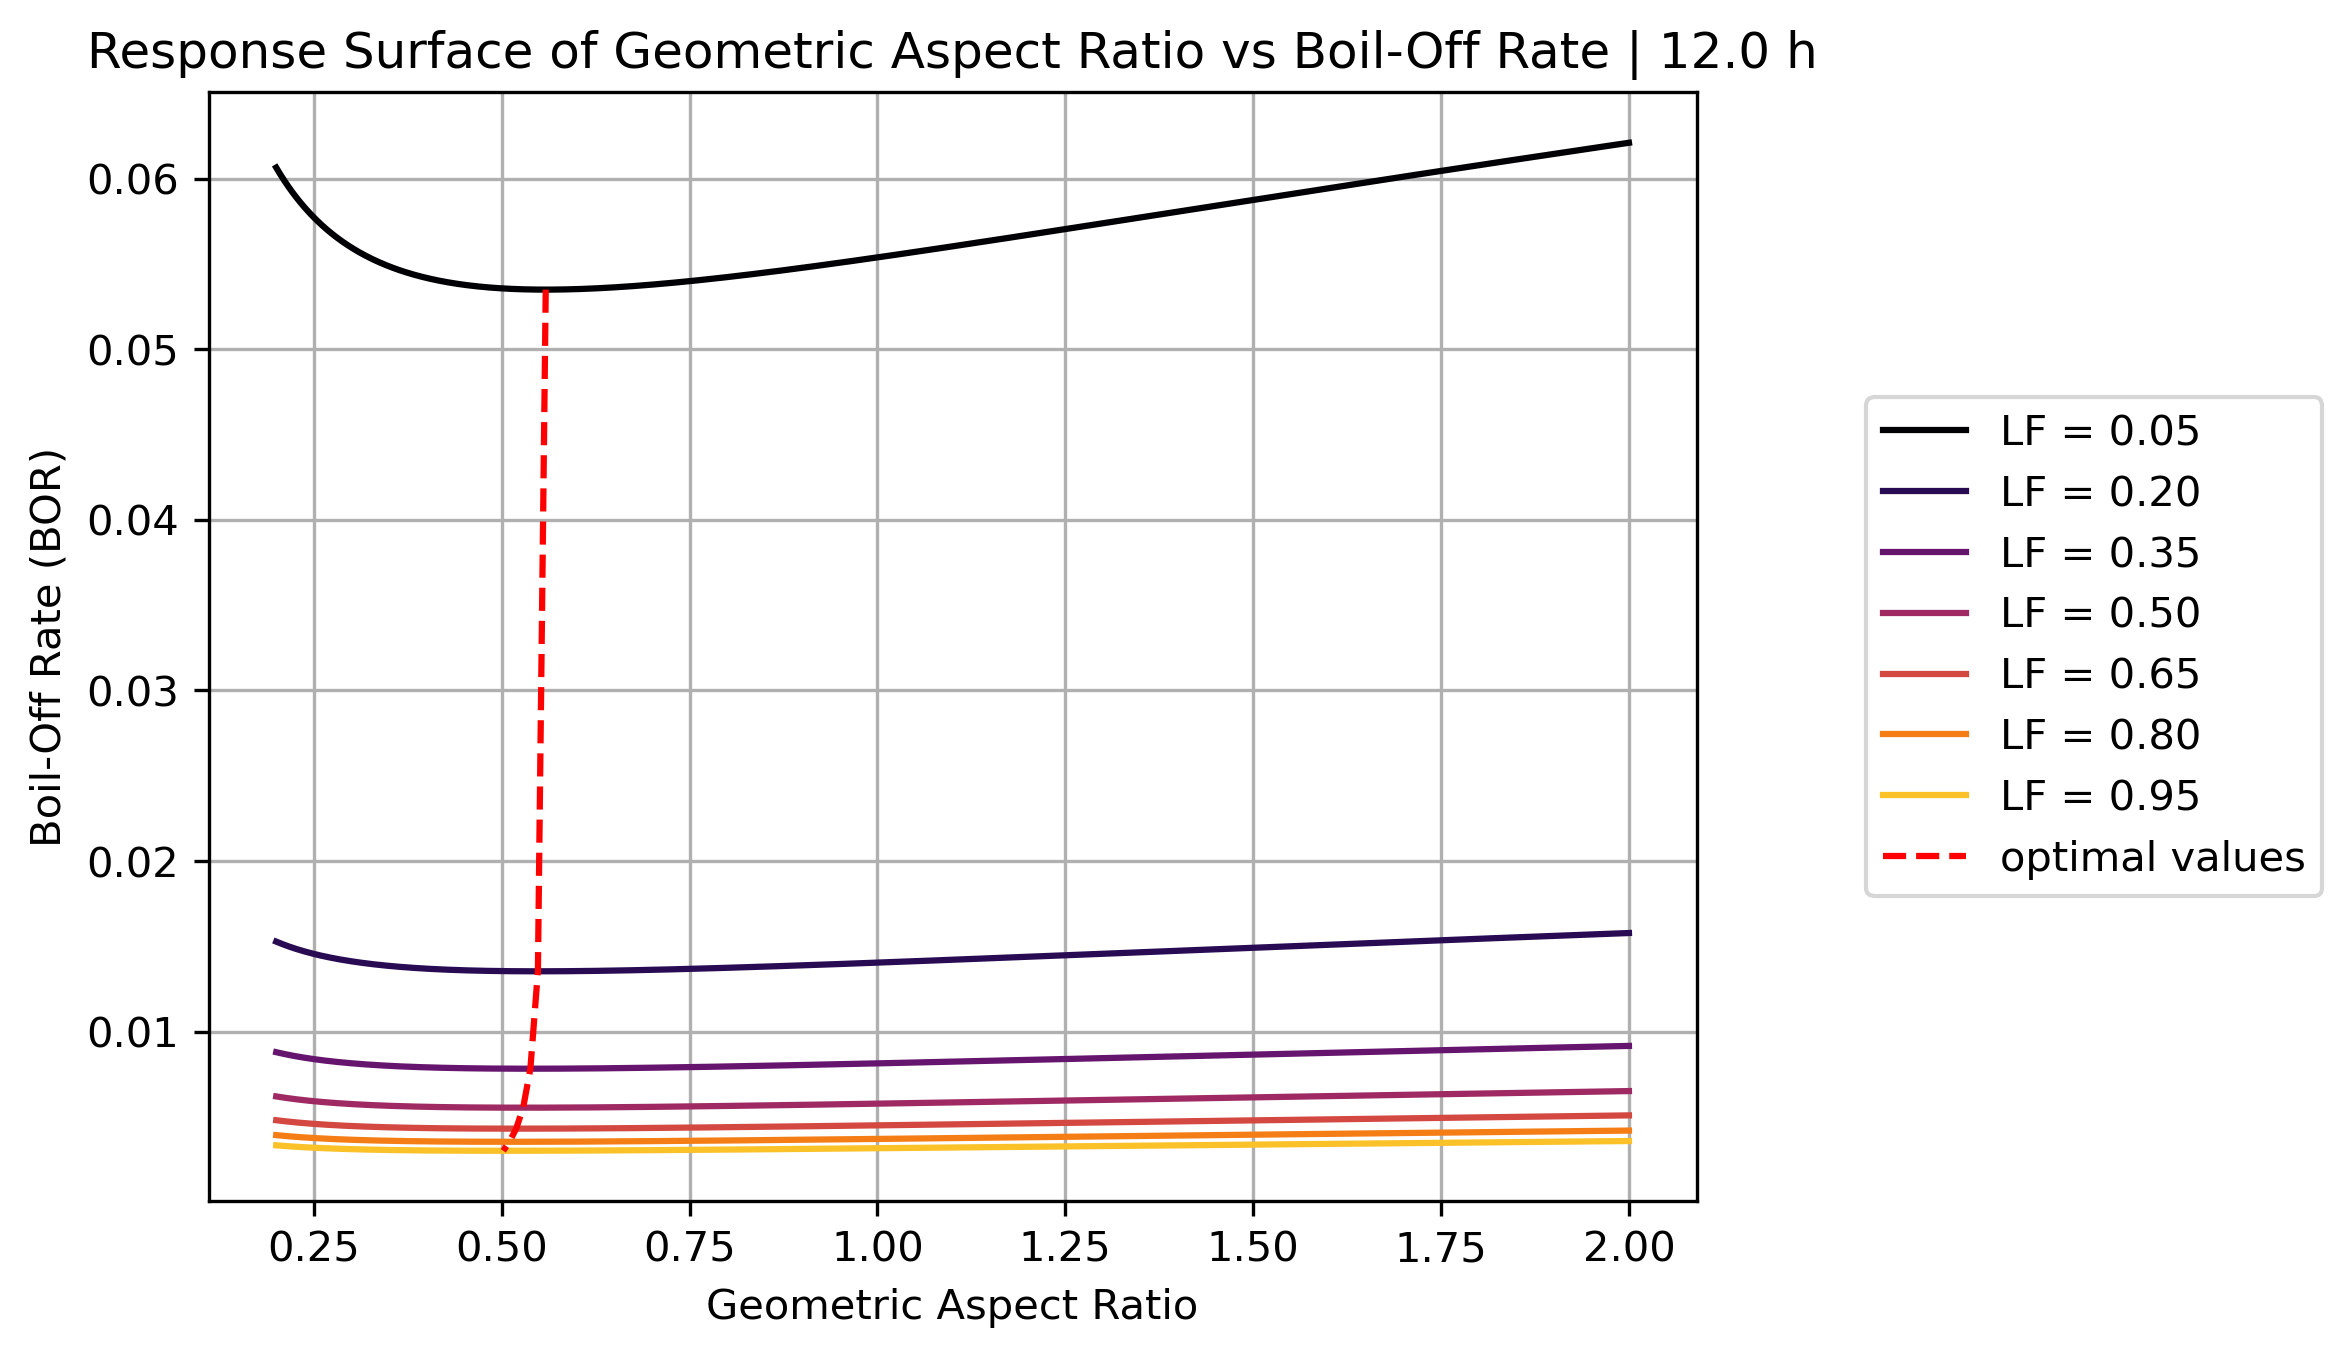

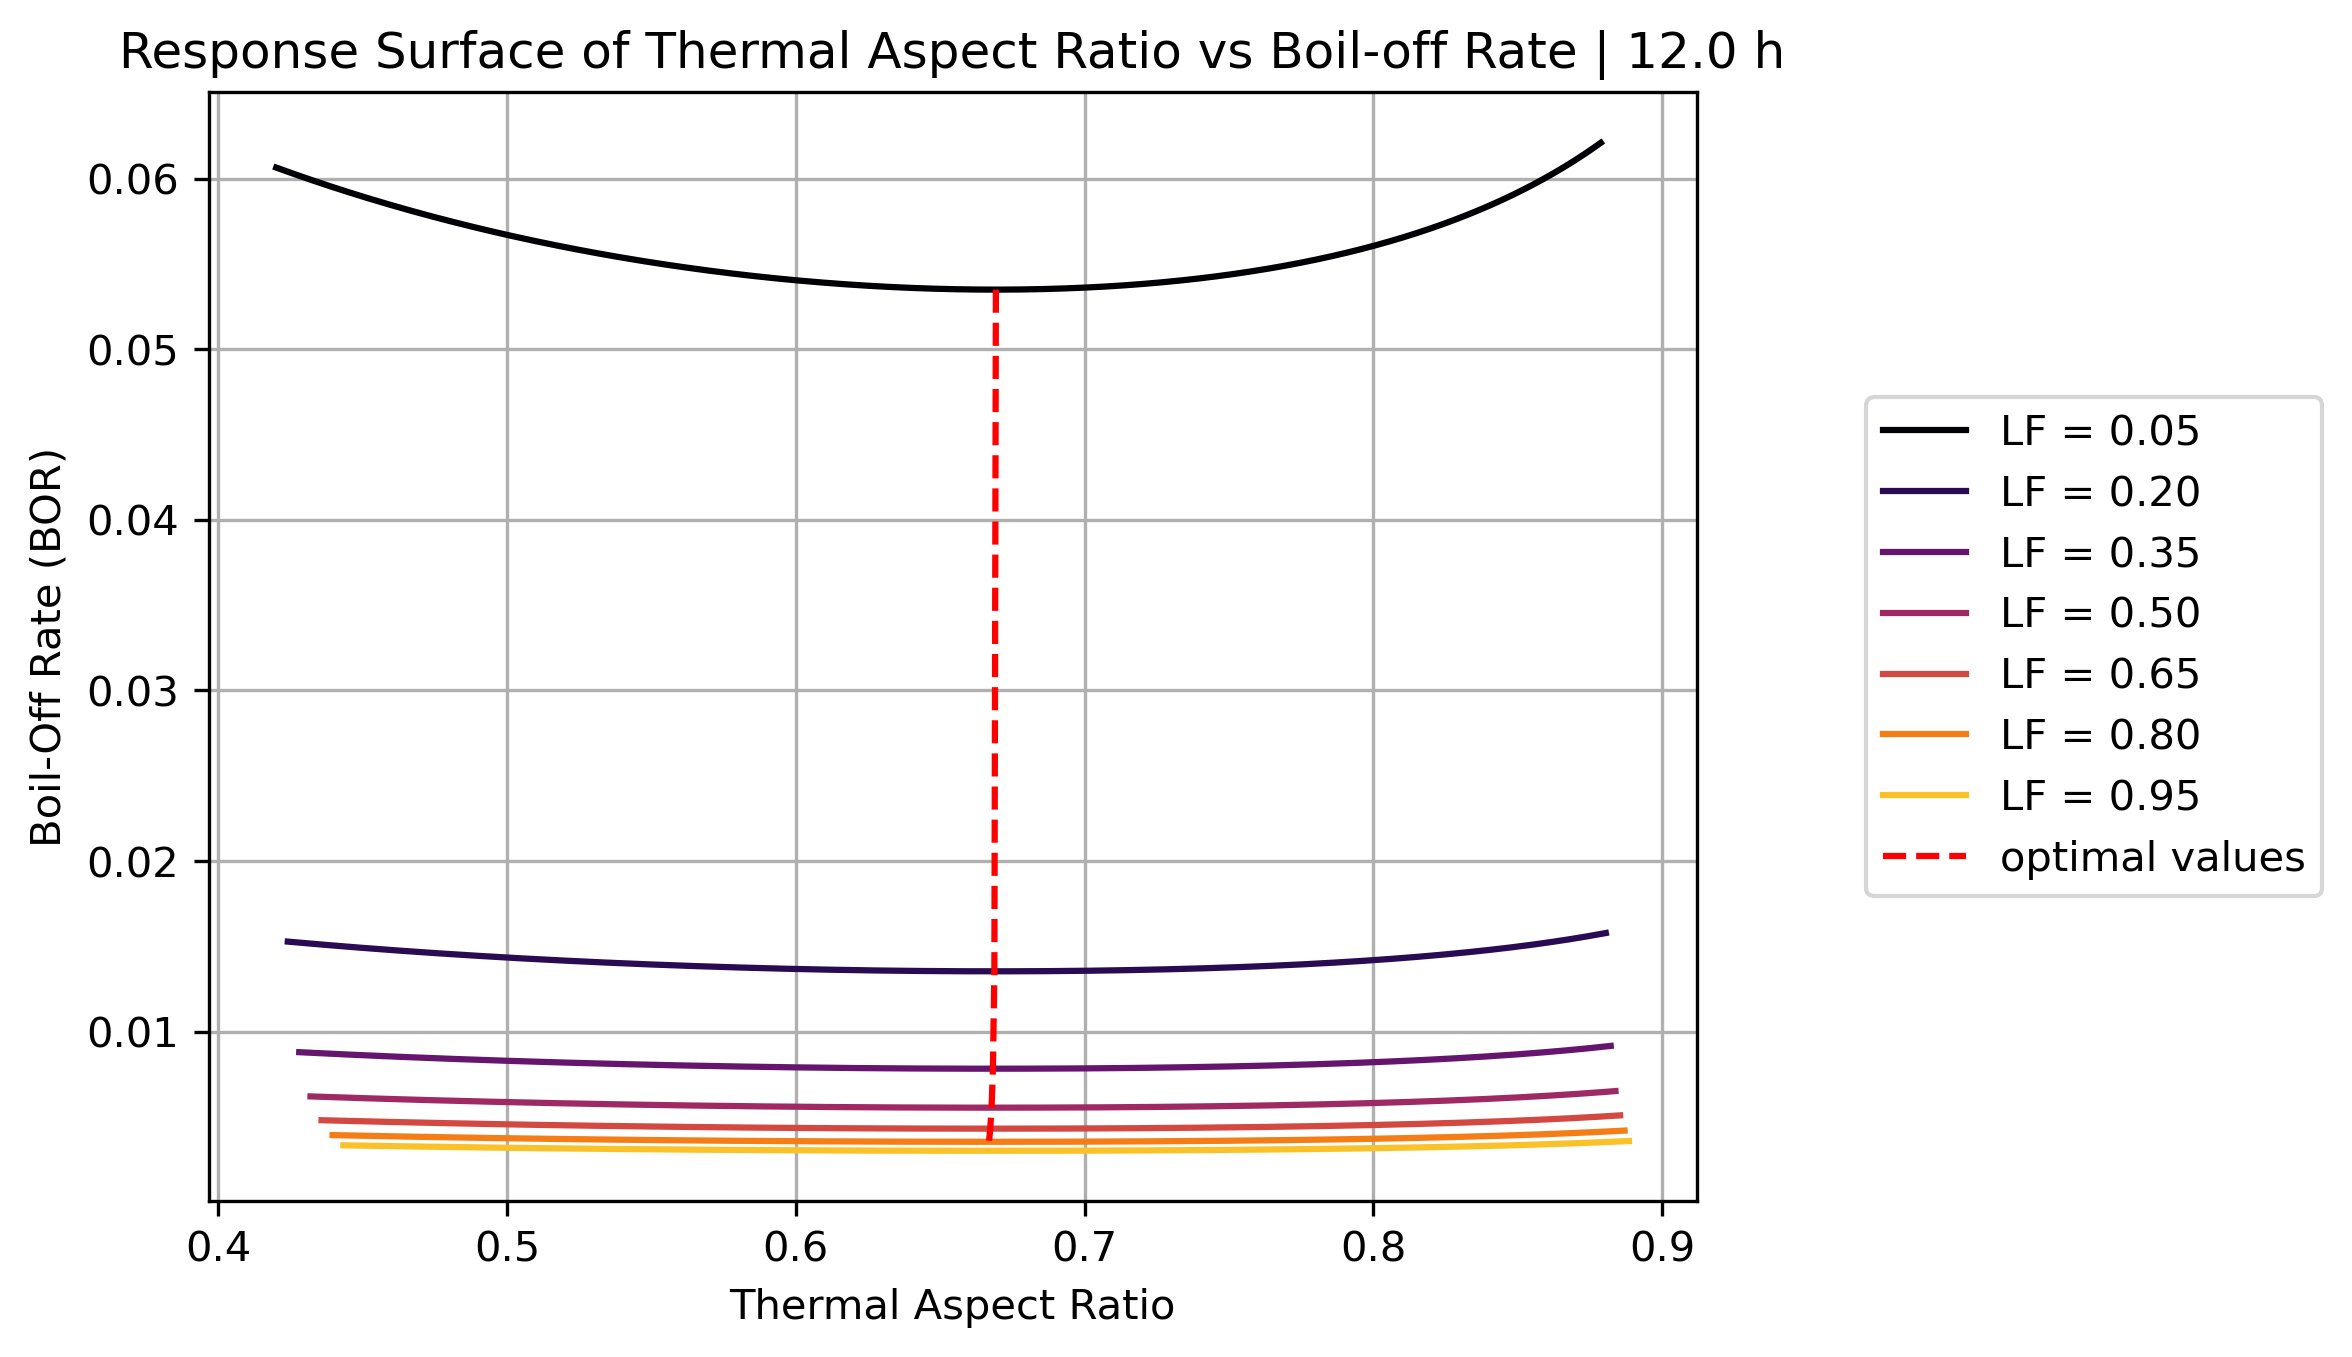

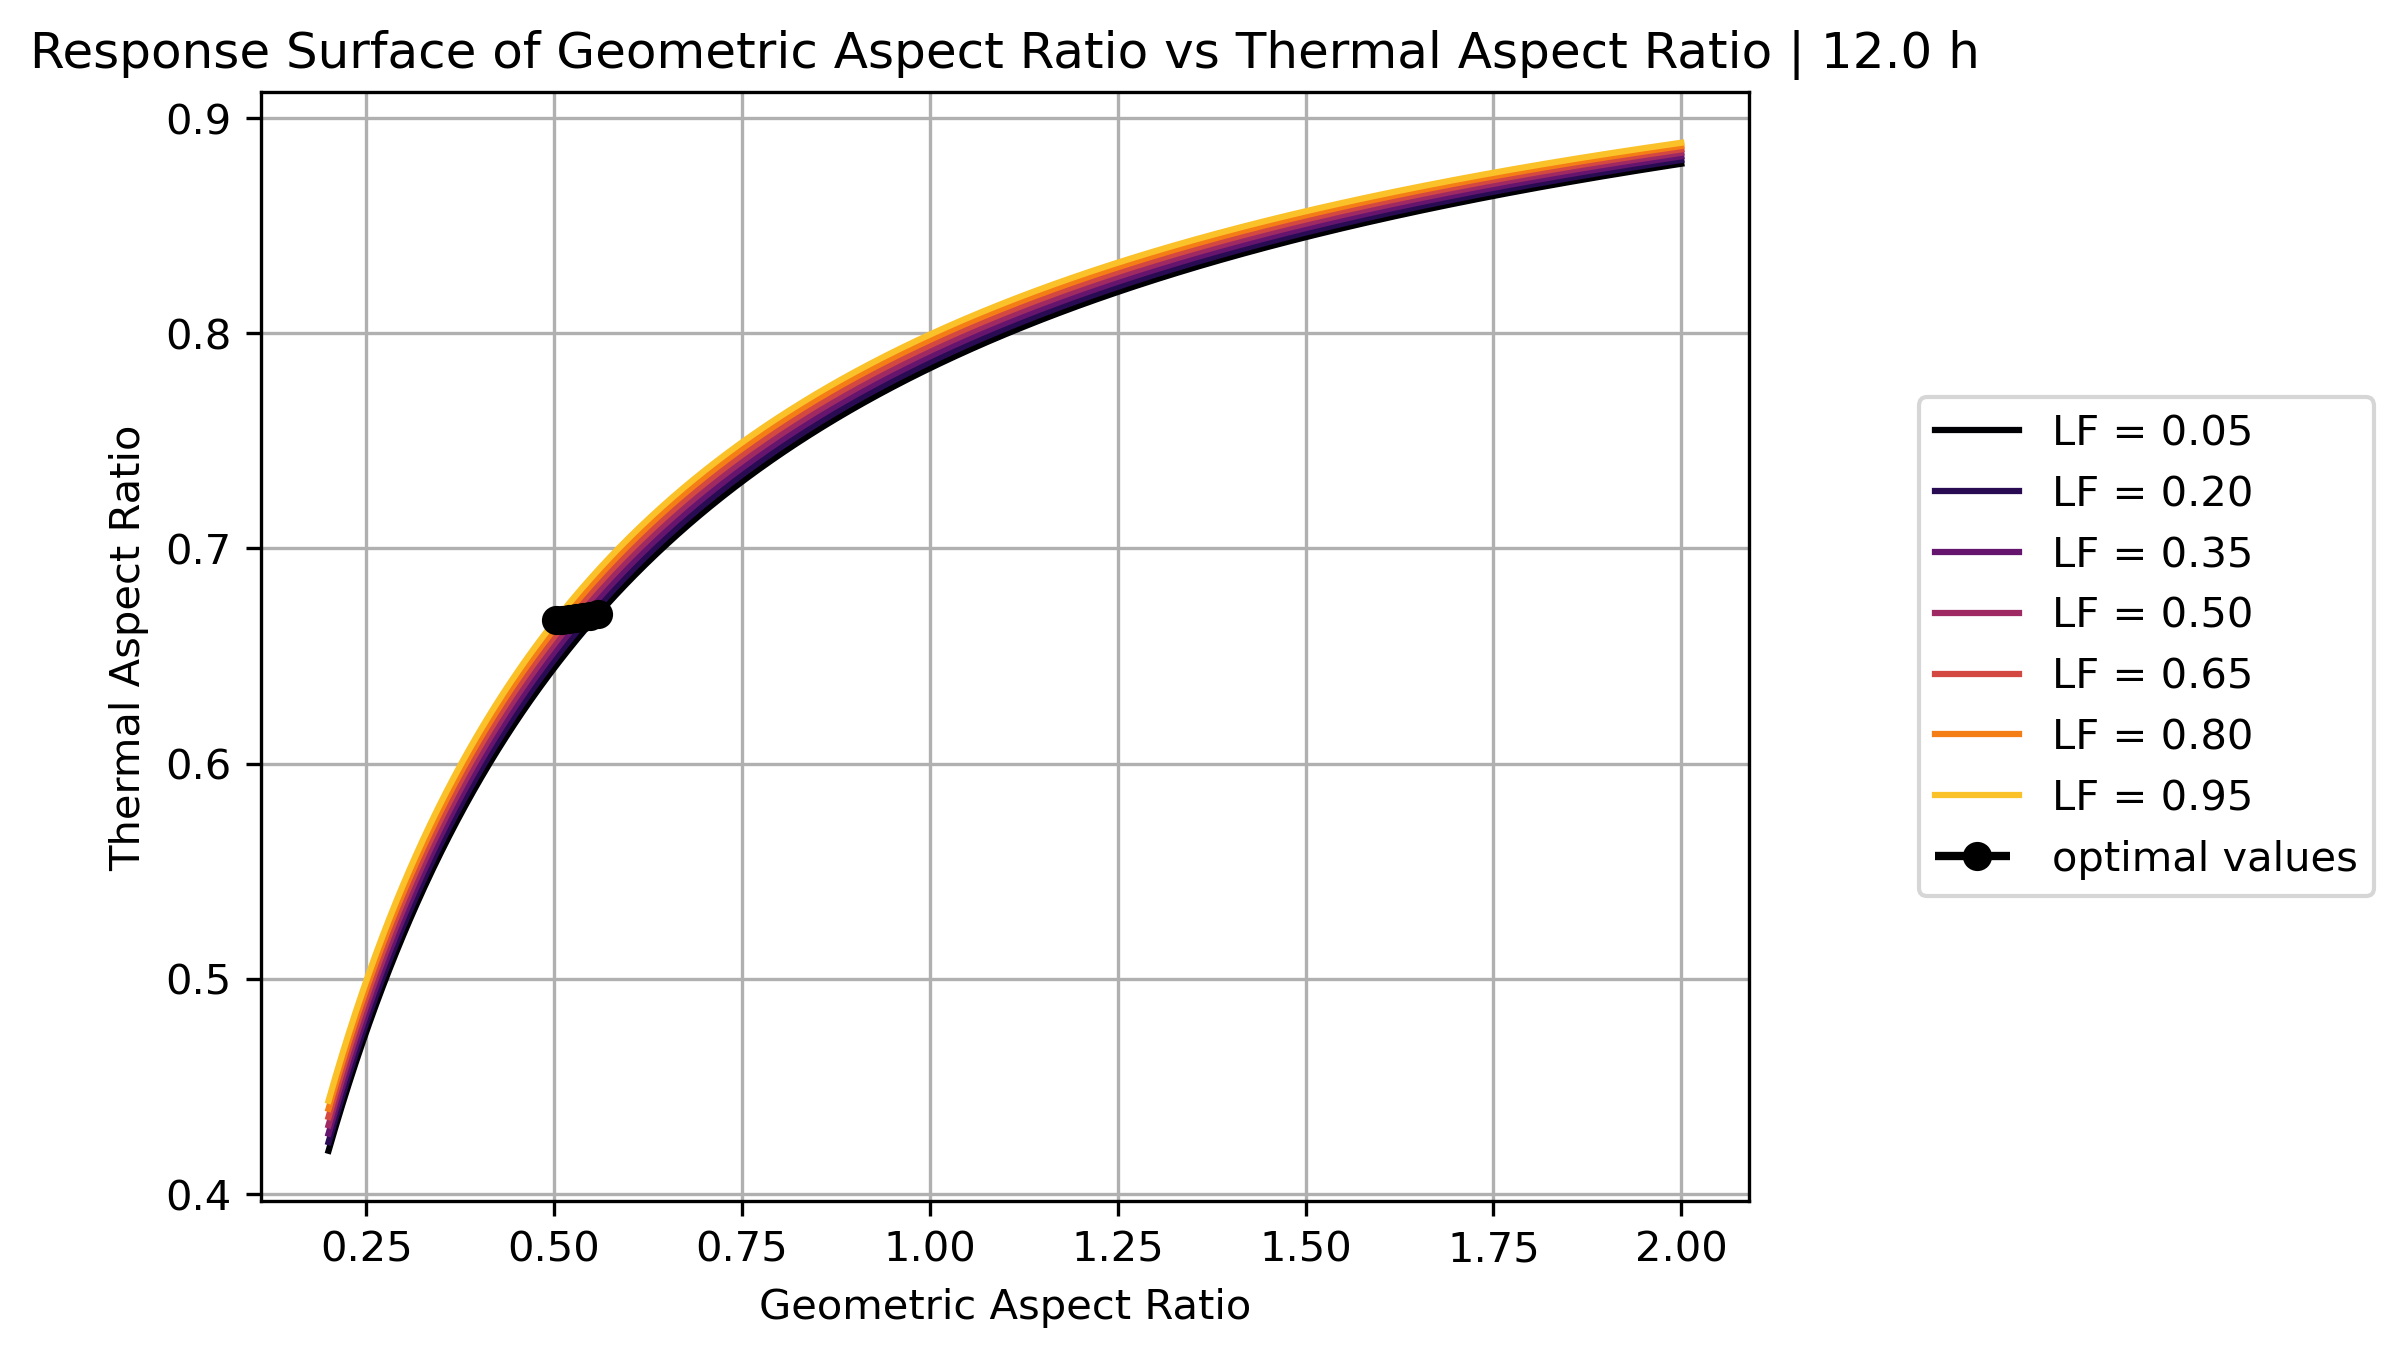

In [16]:
folder = "../Results/"
filename = folder + 'LAES_opti_12h_LFs.csv'
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.2, 2, 1000),
                                                               jnp.linspace(0.05, 0.95, 7),
                                                               12*3600,
                                                               save=True,
                                                               filename=filename)

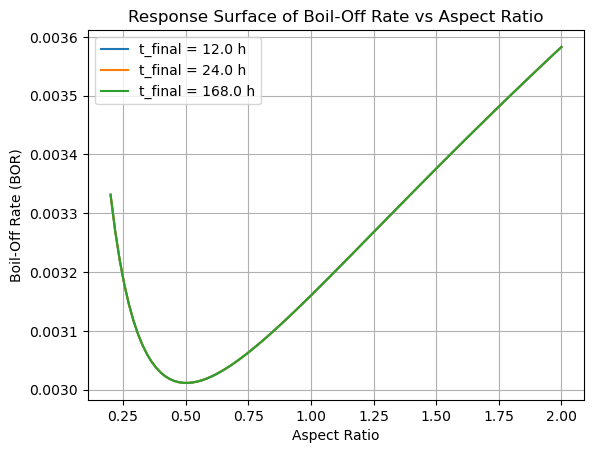

In [7]:
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 12*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 24*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 168*3600)

+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.666663             |
| Optimal Geometric aspect ratio:  0.502068             |
| Minimal BOR:                     0.003011             |
+-------------------------------------------------------------+
Data saved to ../Results/LAES_opti_12h_LFs.csv


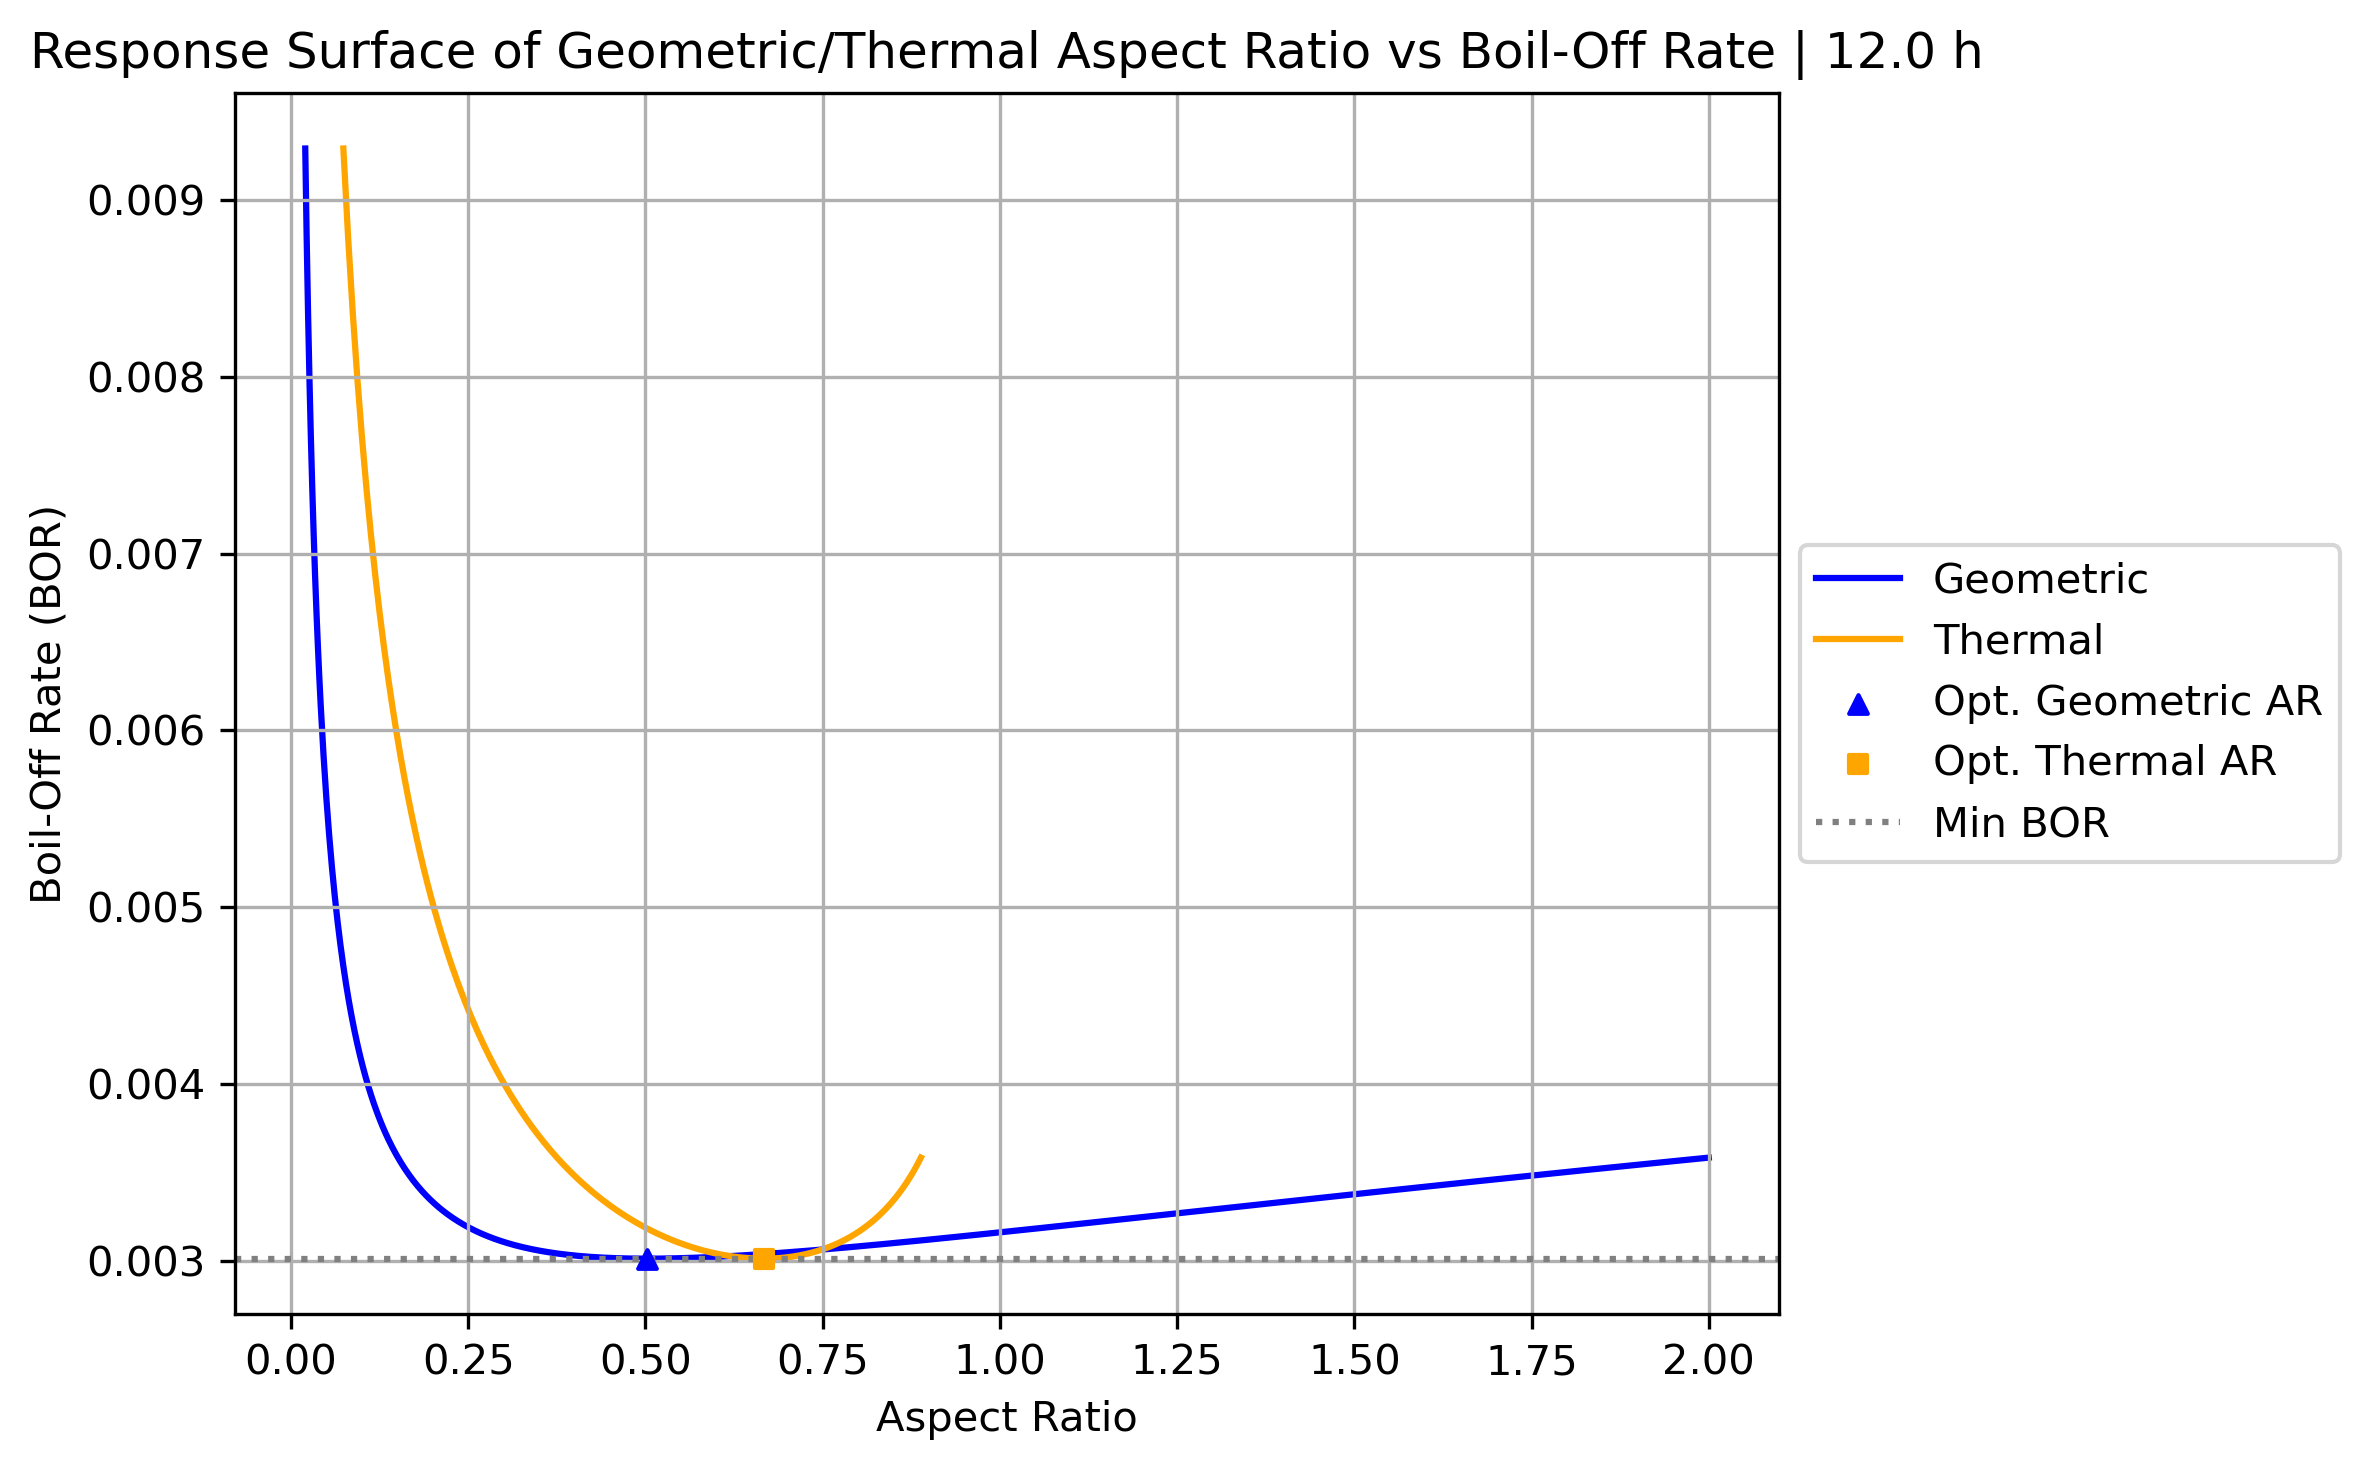

In [18]:
folder = "../Results/"
filename = folder + 'LAES_opti_12h_LFs.csv'
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 2, 1000),
                                        12*3600, save = True,
                                        filename = filename)

optimal Aspect Ratio: [0.56423059 0.55241878 0.54110747 0.53029666 0.51998635 0.51057694
 0.50206843]
optimal Thermal Aspect Ratio: [0.67152342 0.67048051 0.66948071 0.66853478 0.66765364 0.6670227
 0.66666288]
optimal BOR: [0.0533199  0.01349839 0.00780877 0.00553225 0.00430569 0.00353804
 0.00301132]


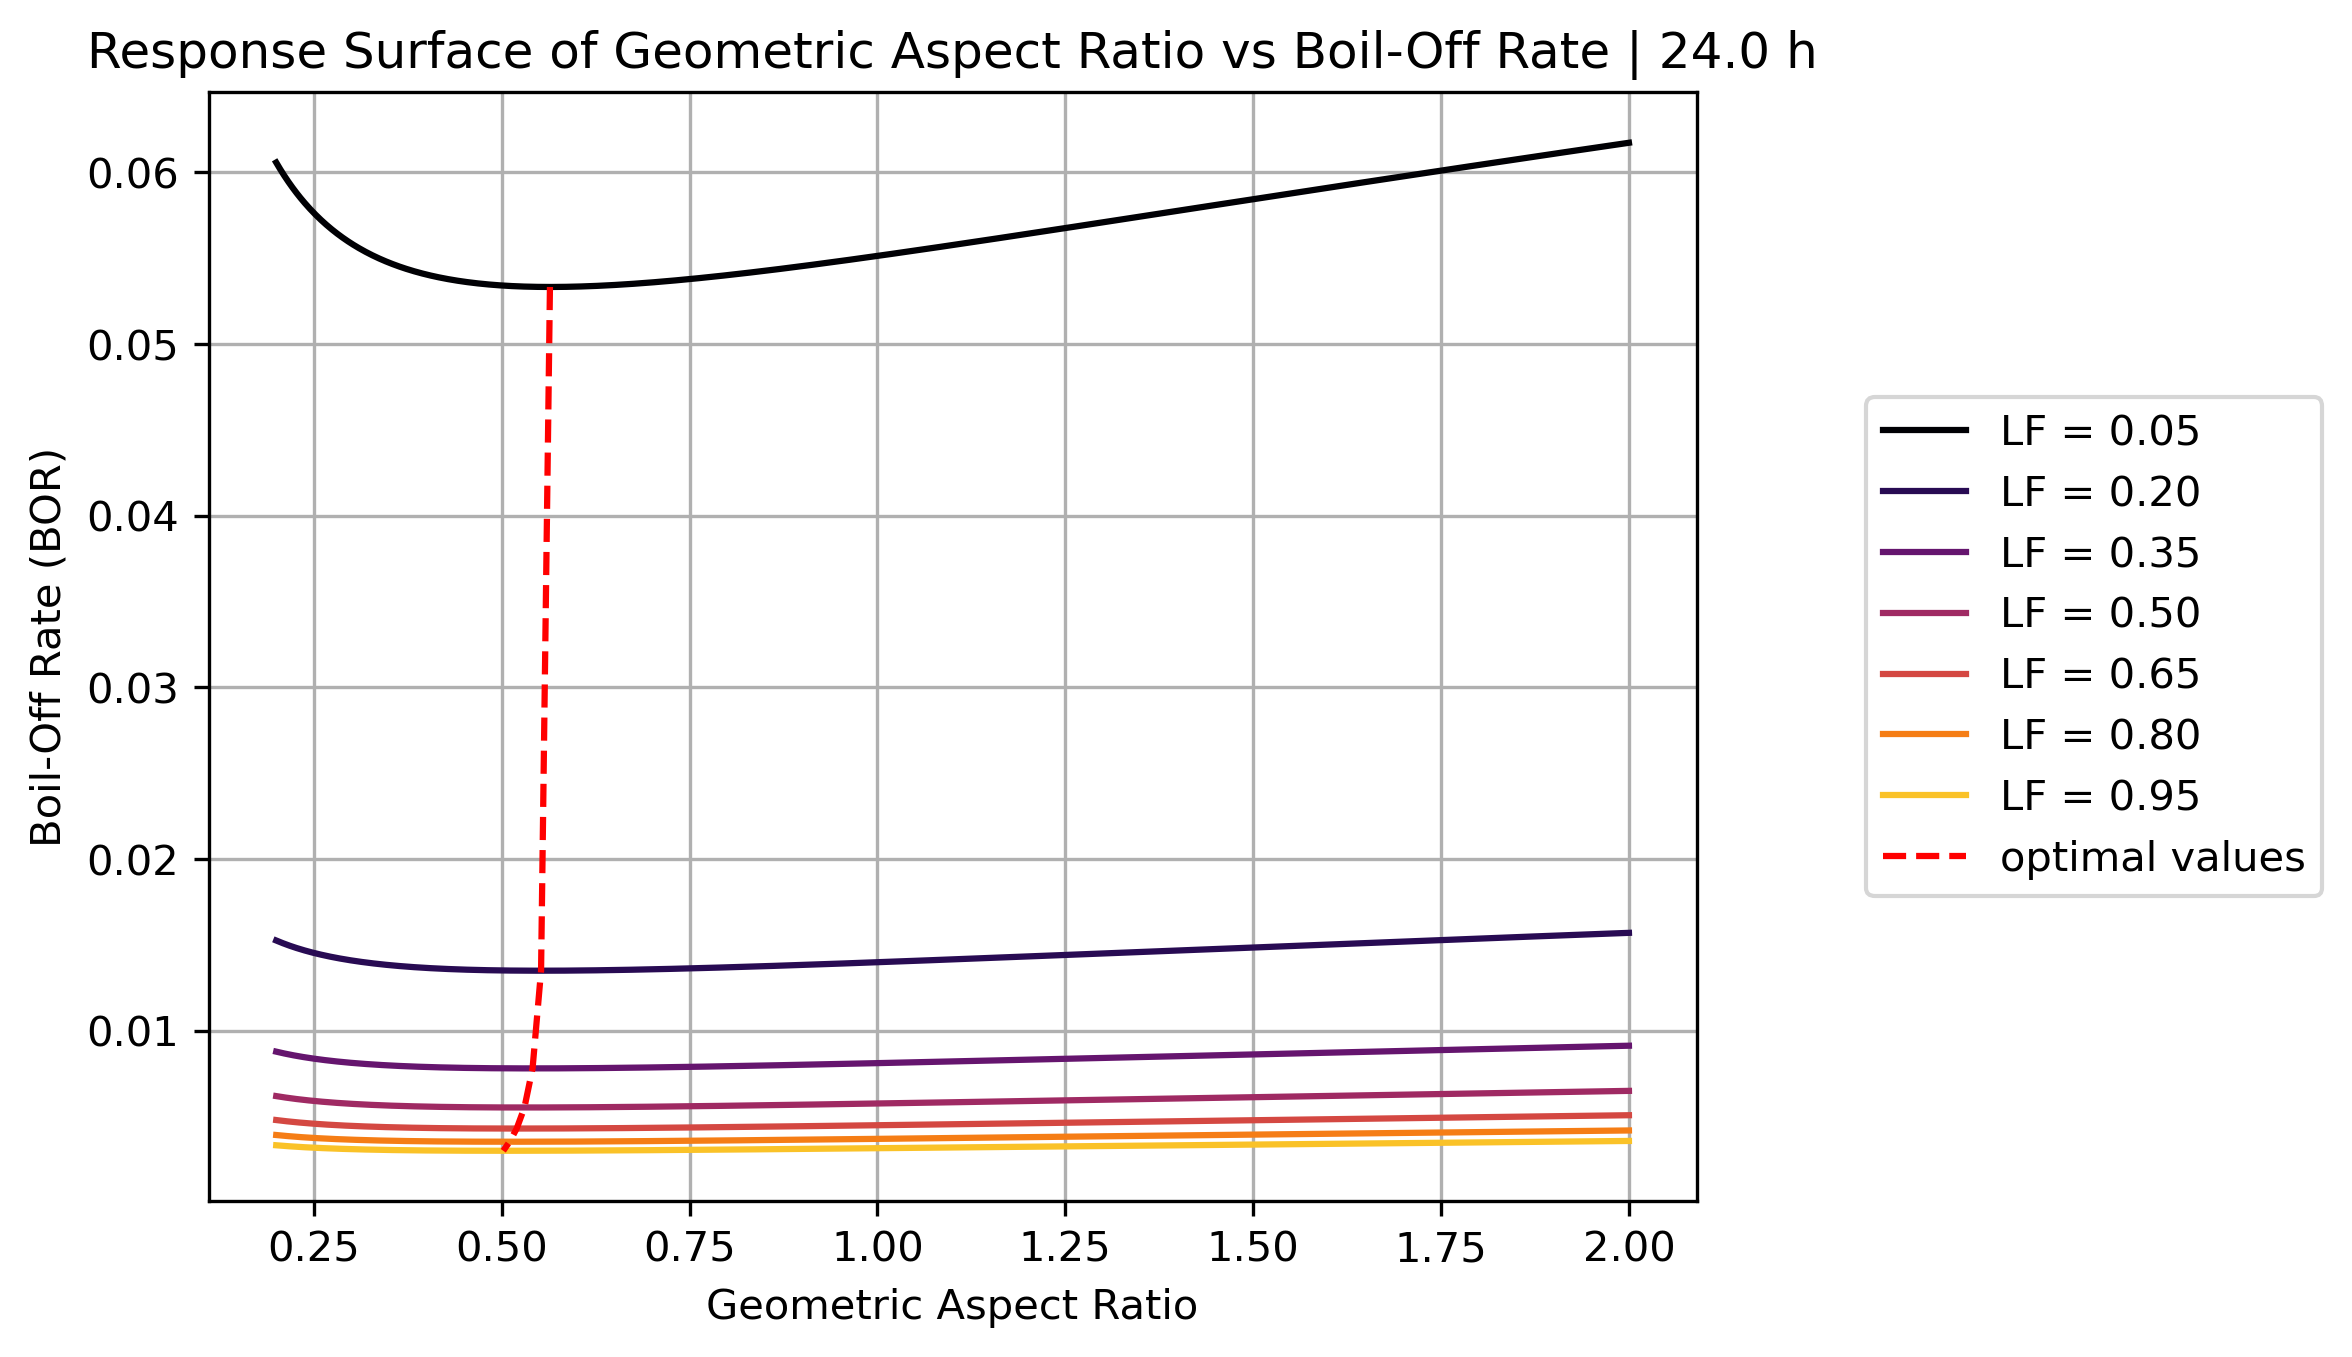

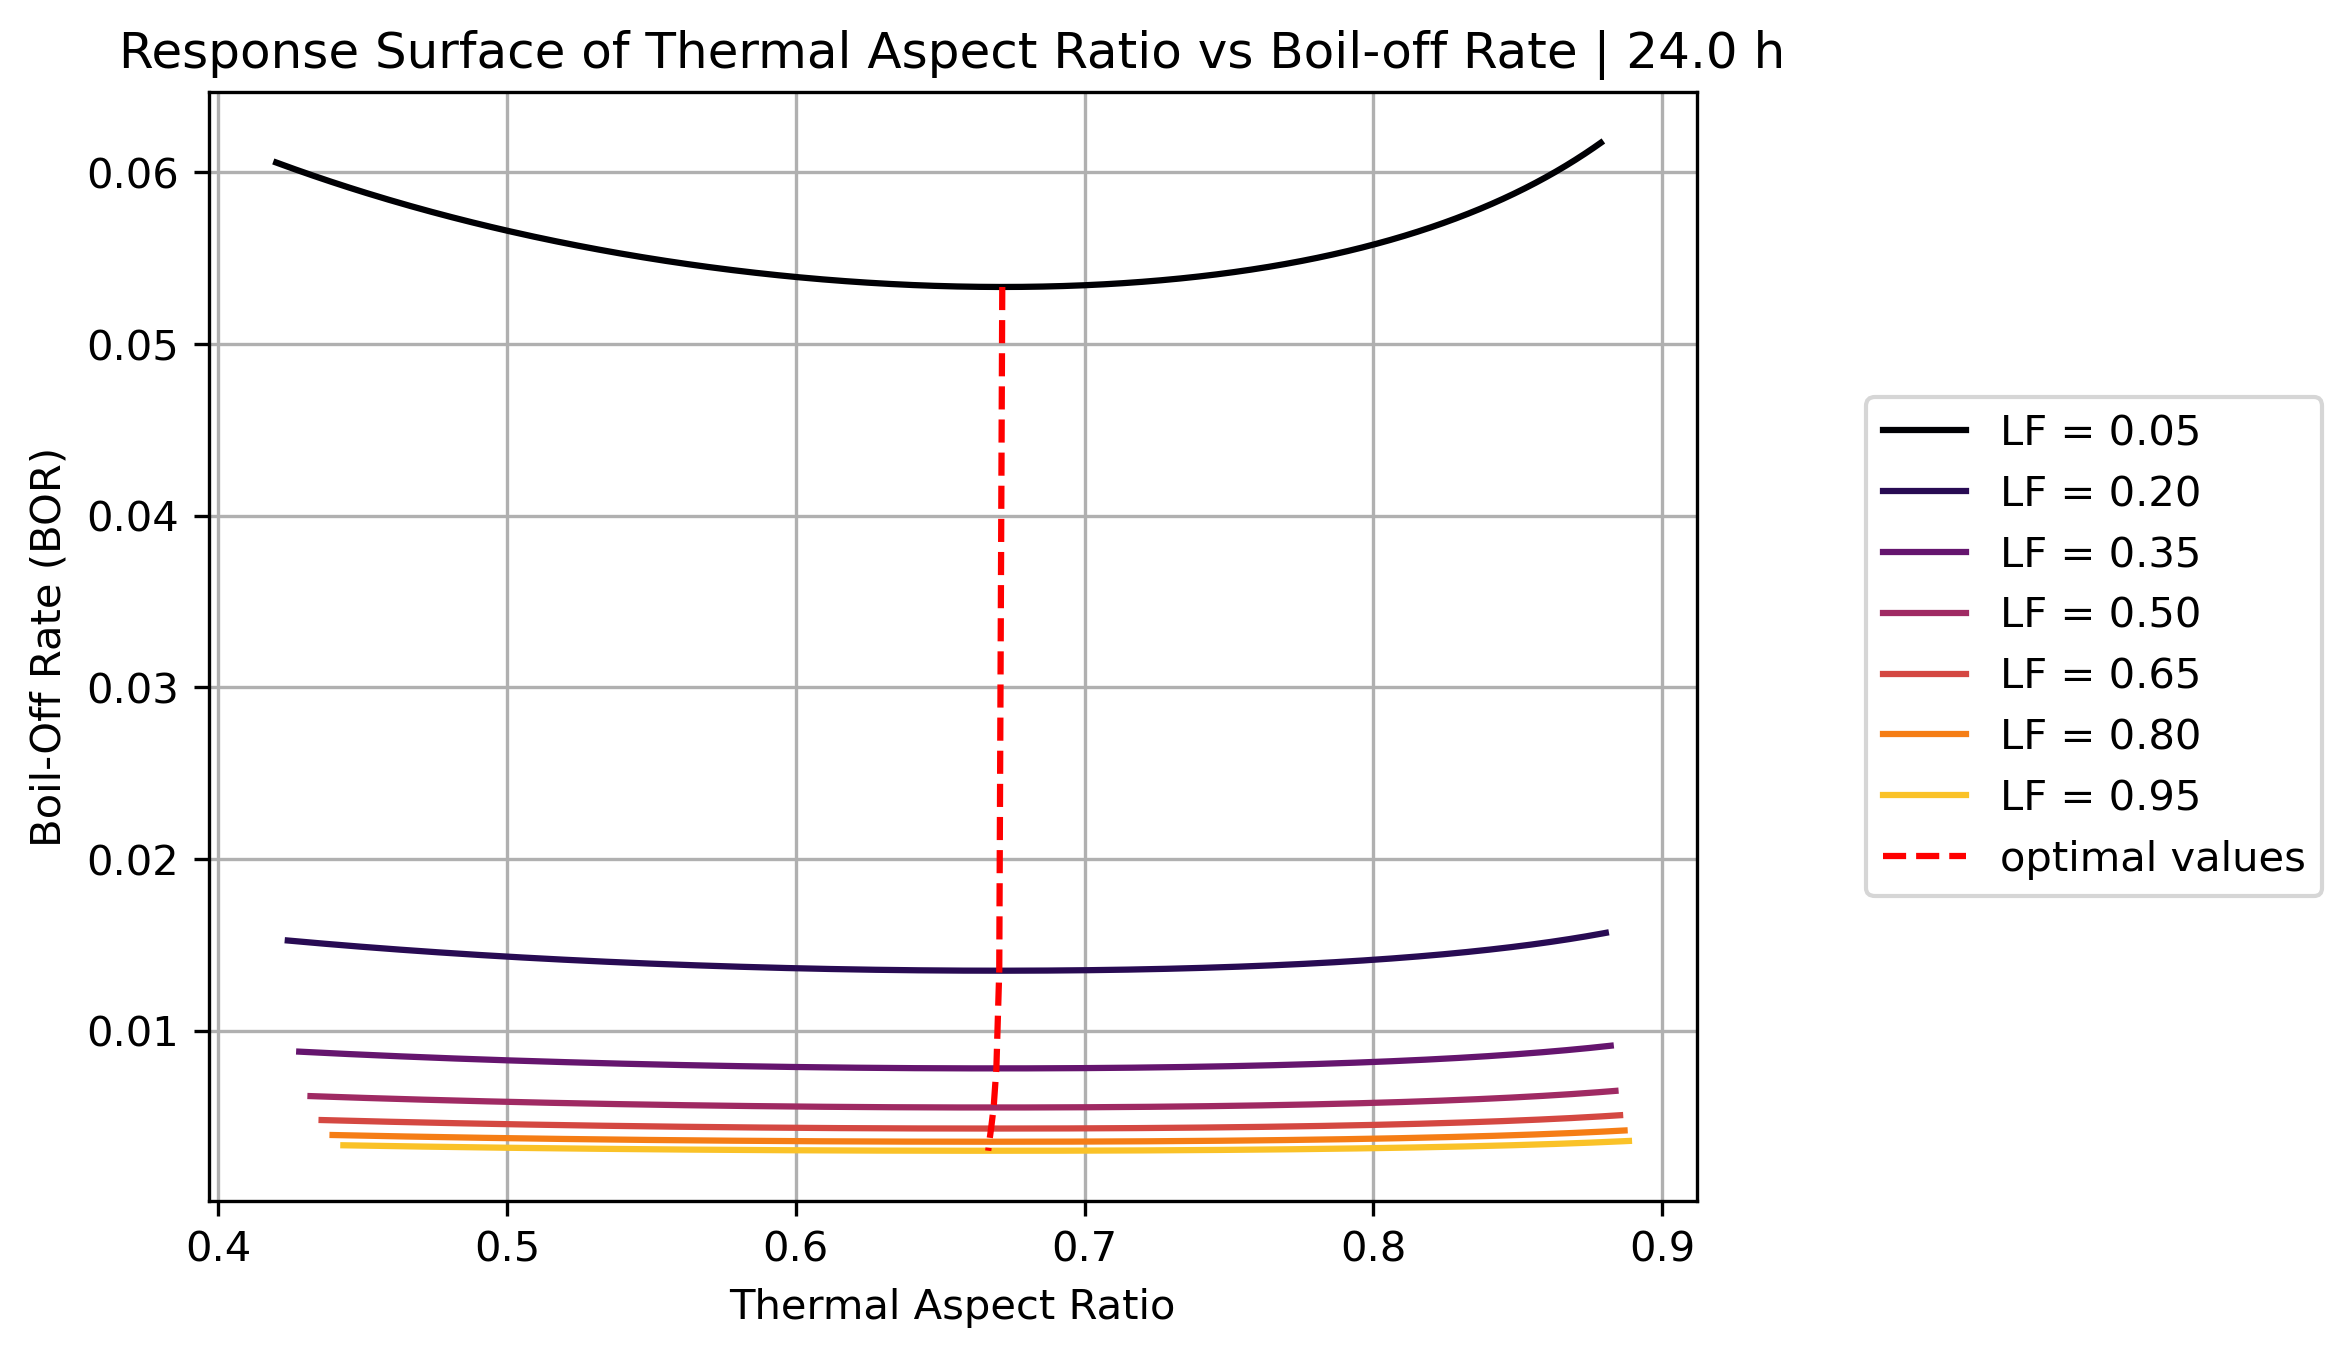

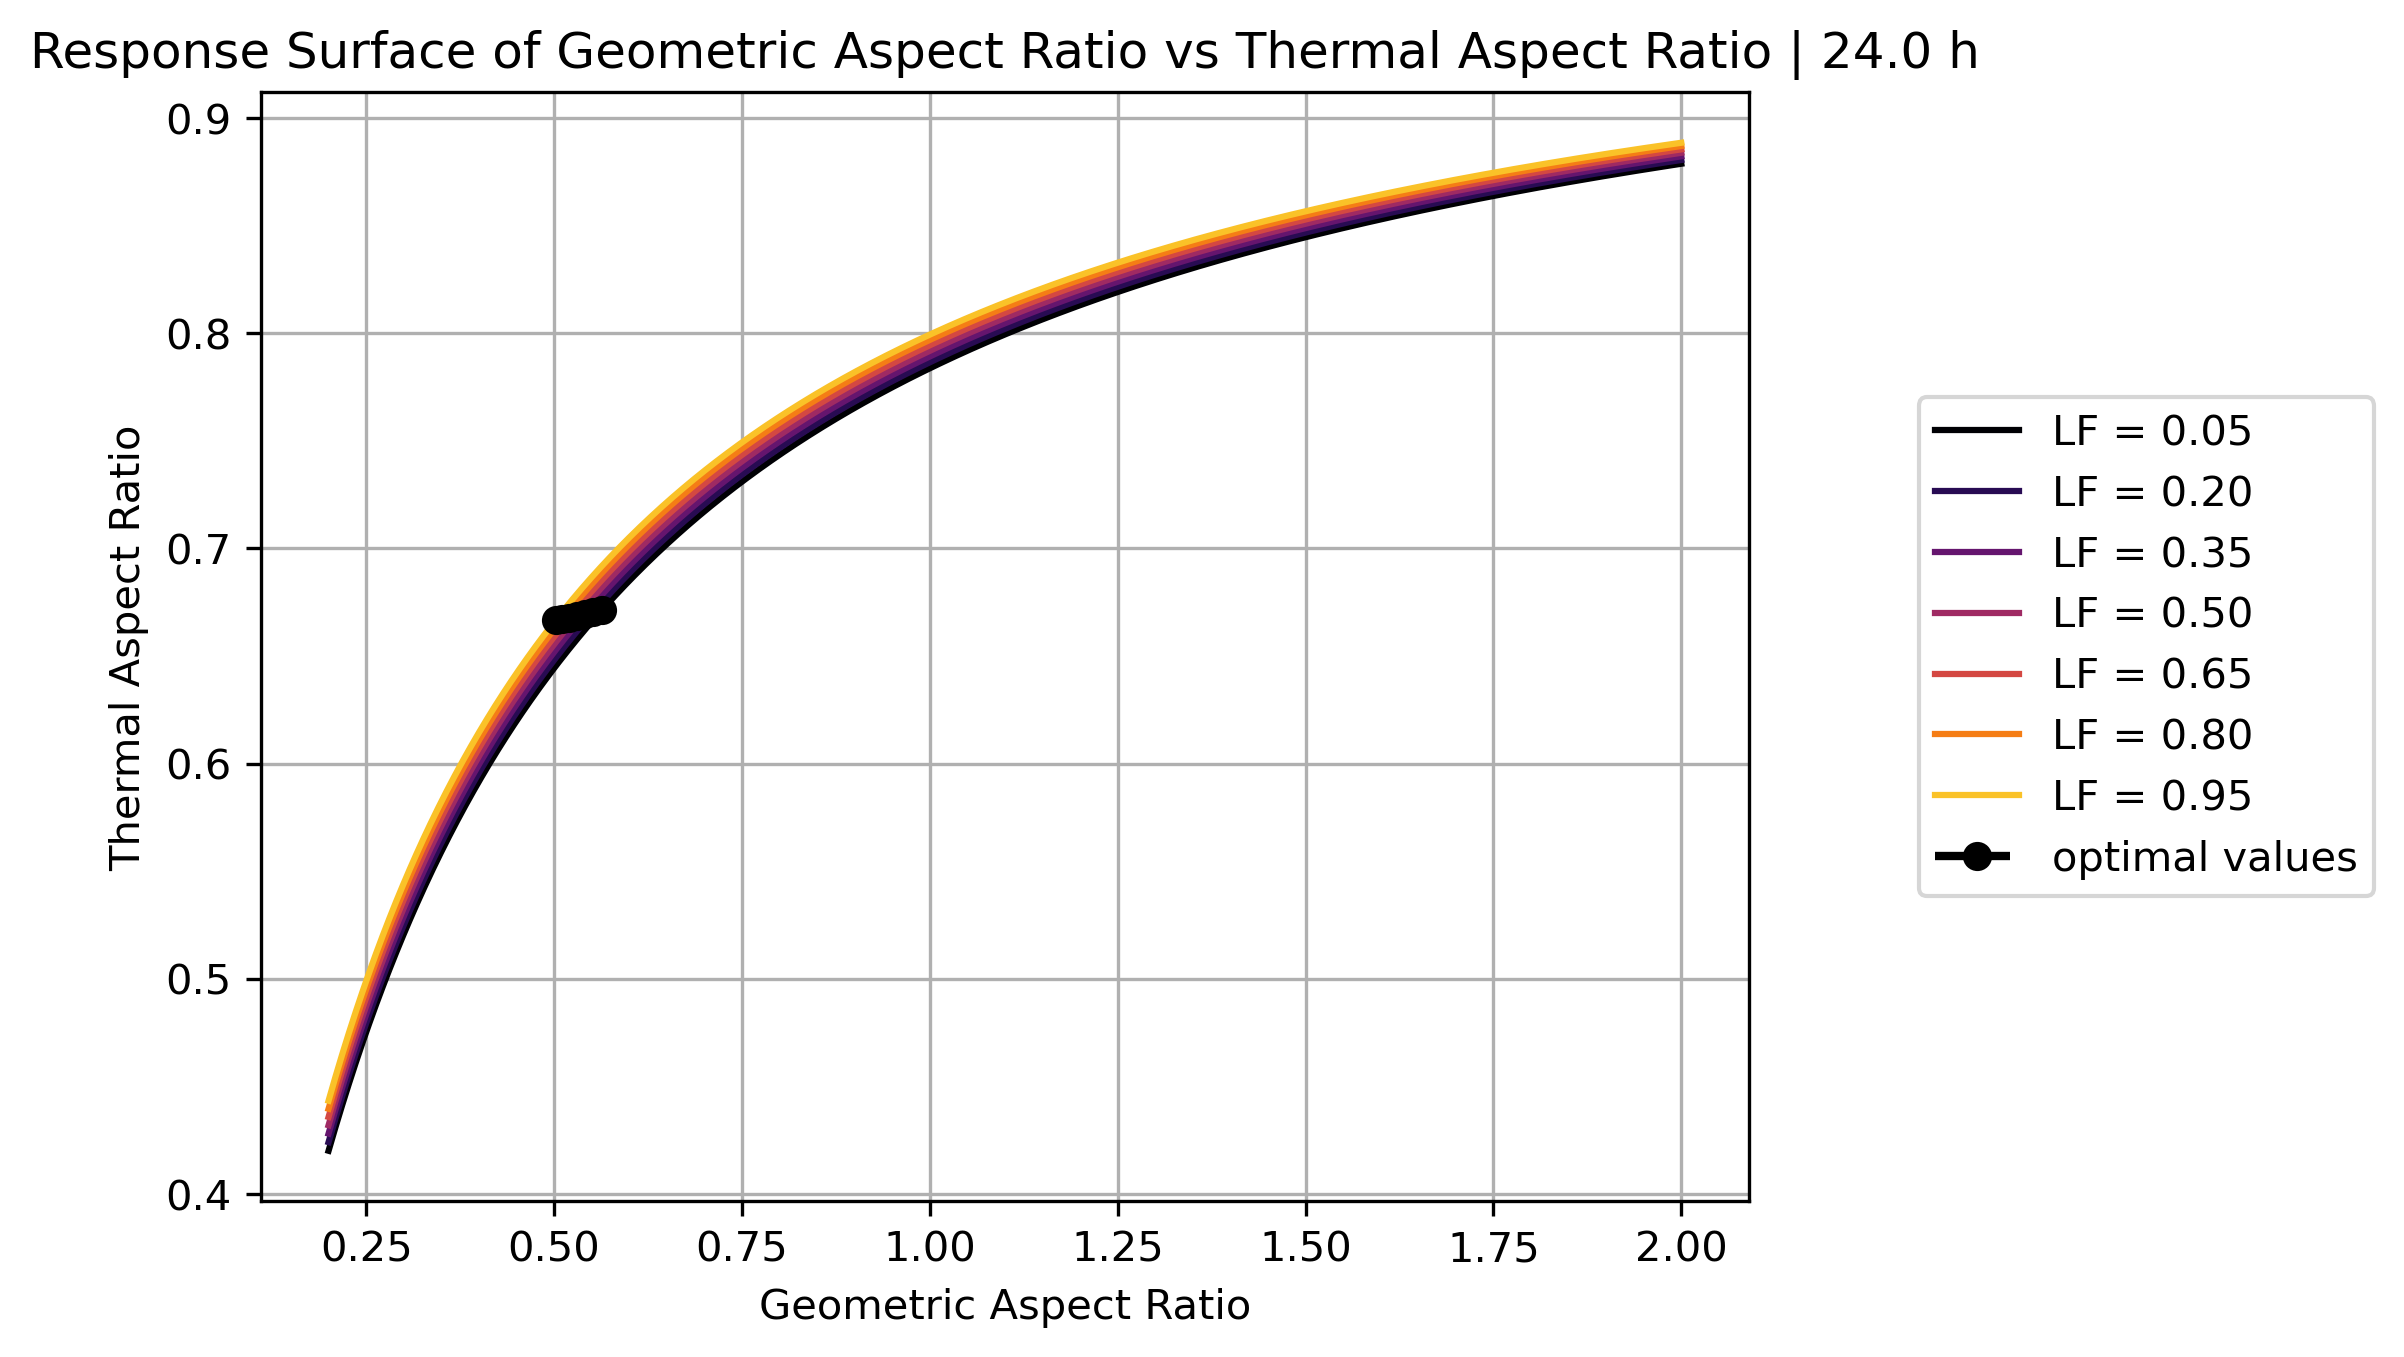

In [19]:
folder = "../Results/"
filename = folder + 'LAES_opti_24h_LFs.csv'
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.2, 2, 1000),
                                                               jnp.linspace(0.05, 0.95, 7),
                                                               24*3600,
                                                               save=True,
                                                               filename=filename)

optimal Aspect Ratio: [0.57995359 0.56182819 0.54611248 0.53249886 0.52078715 0.51067704
 0.50206843]
optimal Thermal Aspect Ratio: [0.67755905 0.67420236 0.67151543 0.66945274 0.66799511 0.66706625
 0.66666288]
optimal BOR: [0.05284407 0.01342367 0.00778488 0.00552445 0.00430364 0.00353775
 0.00301132]


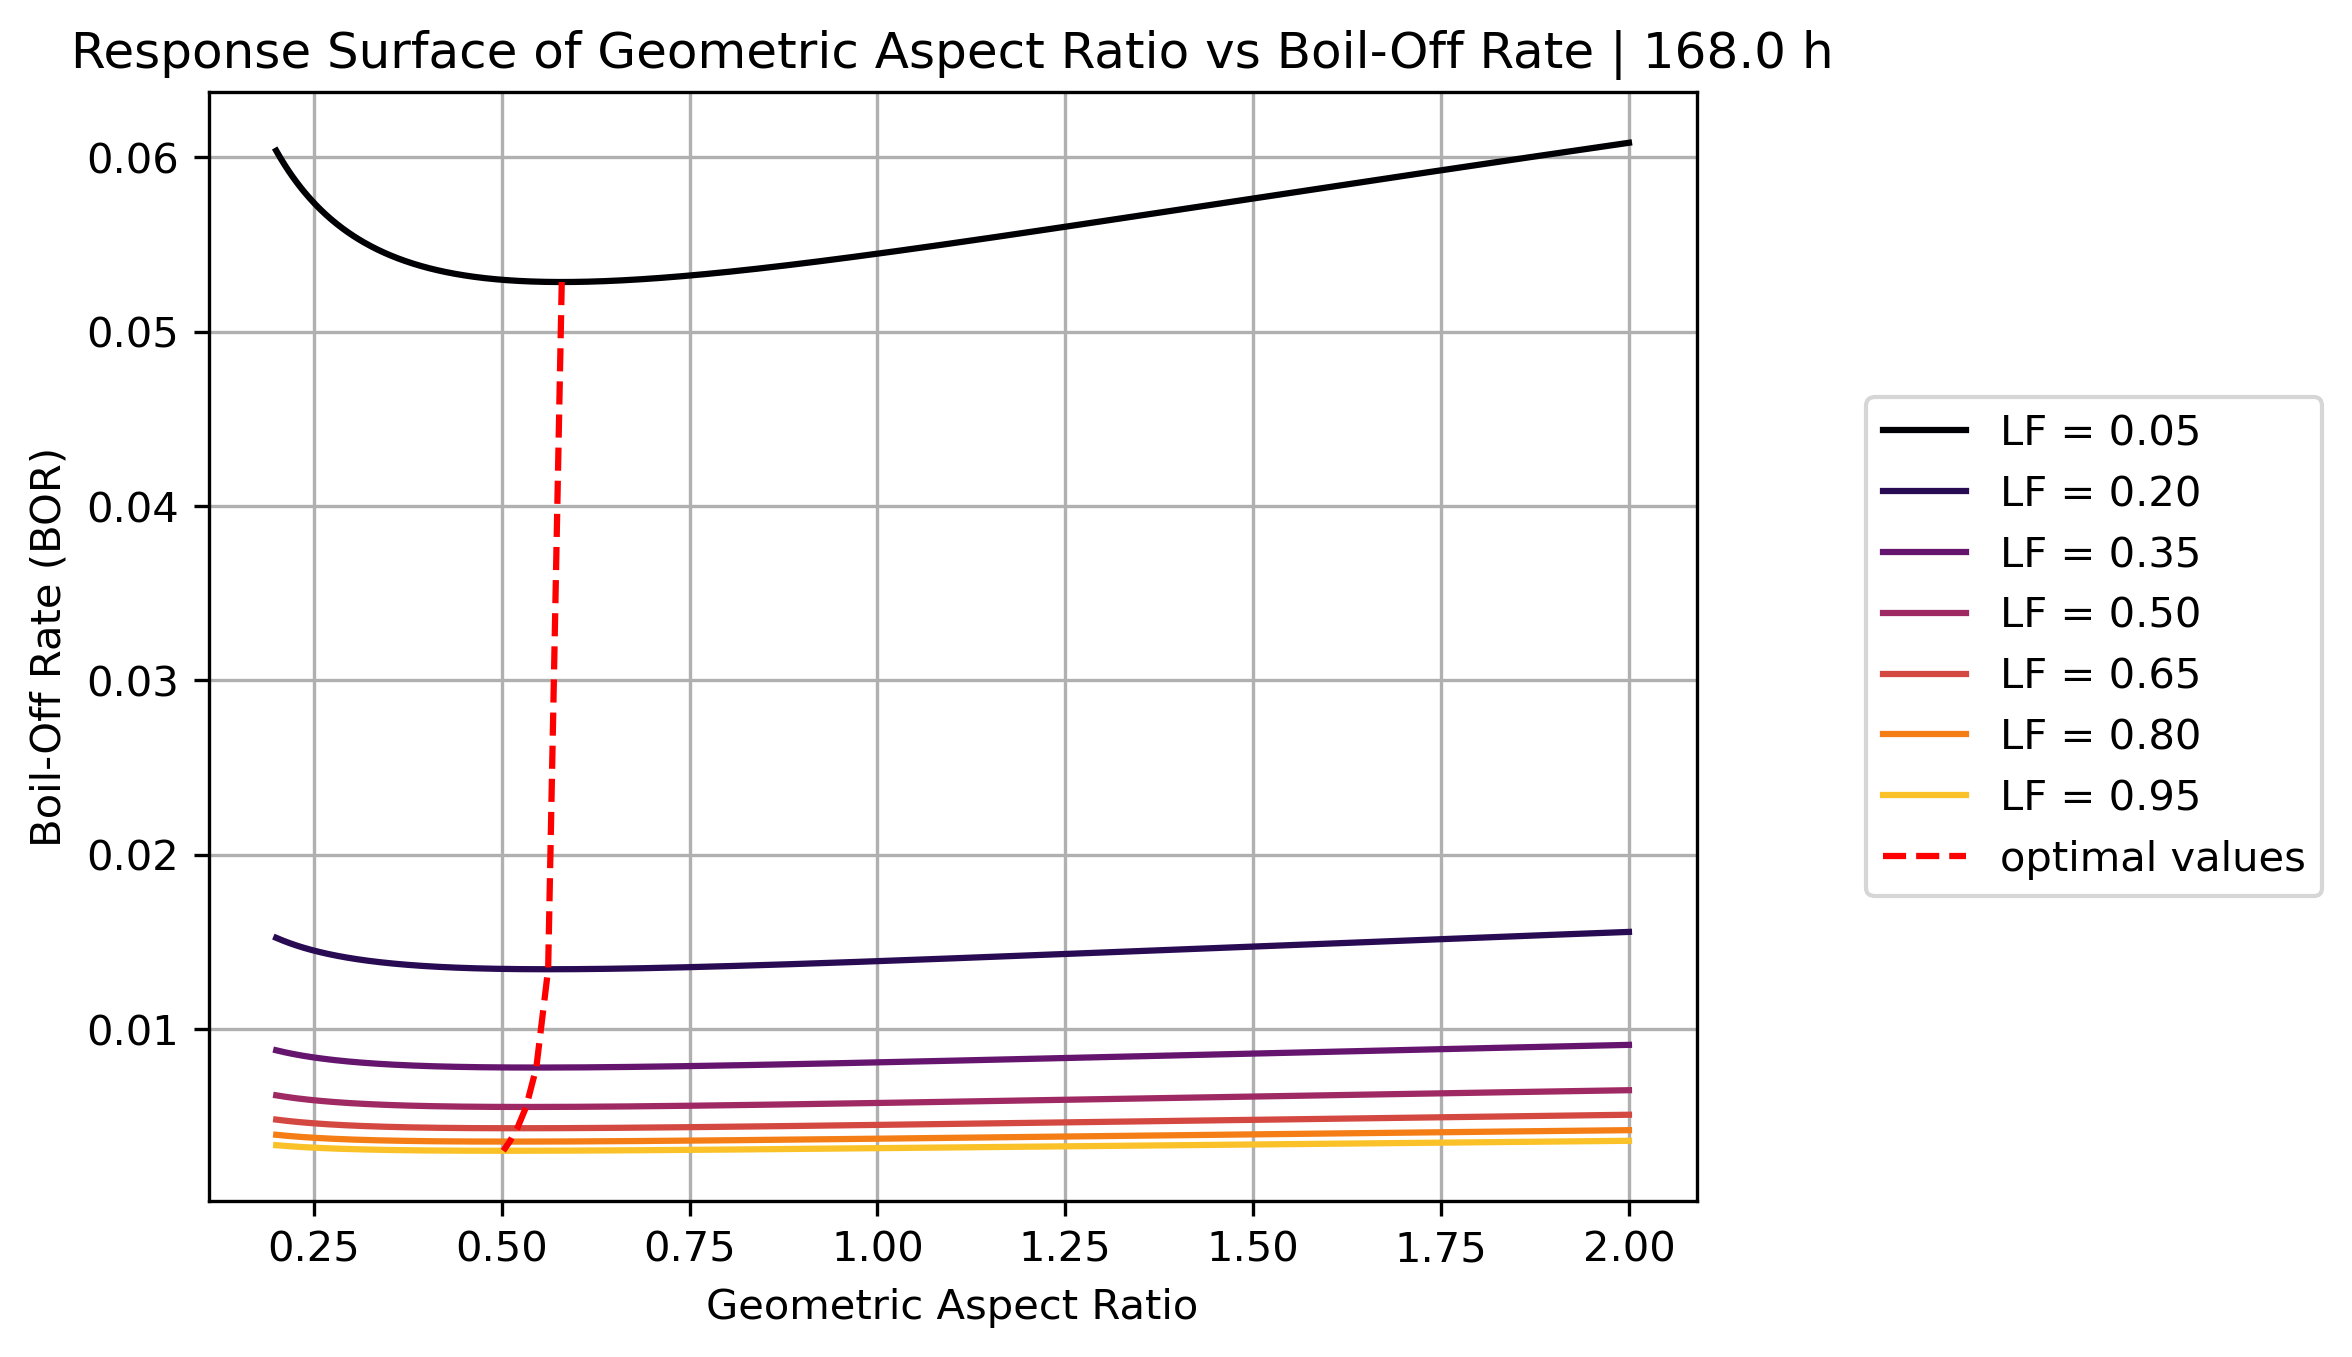

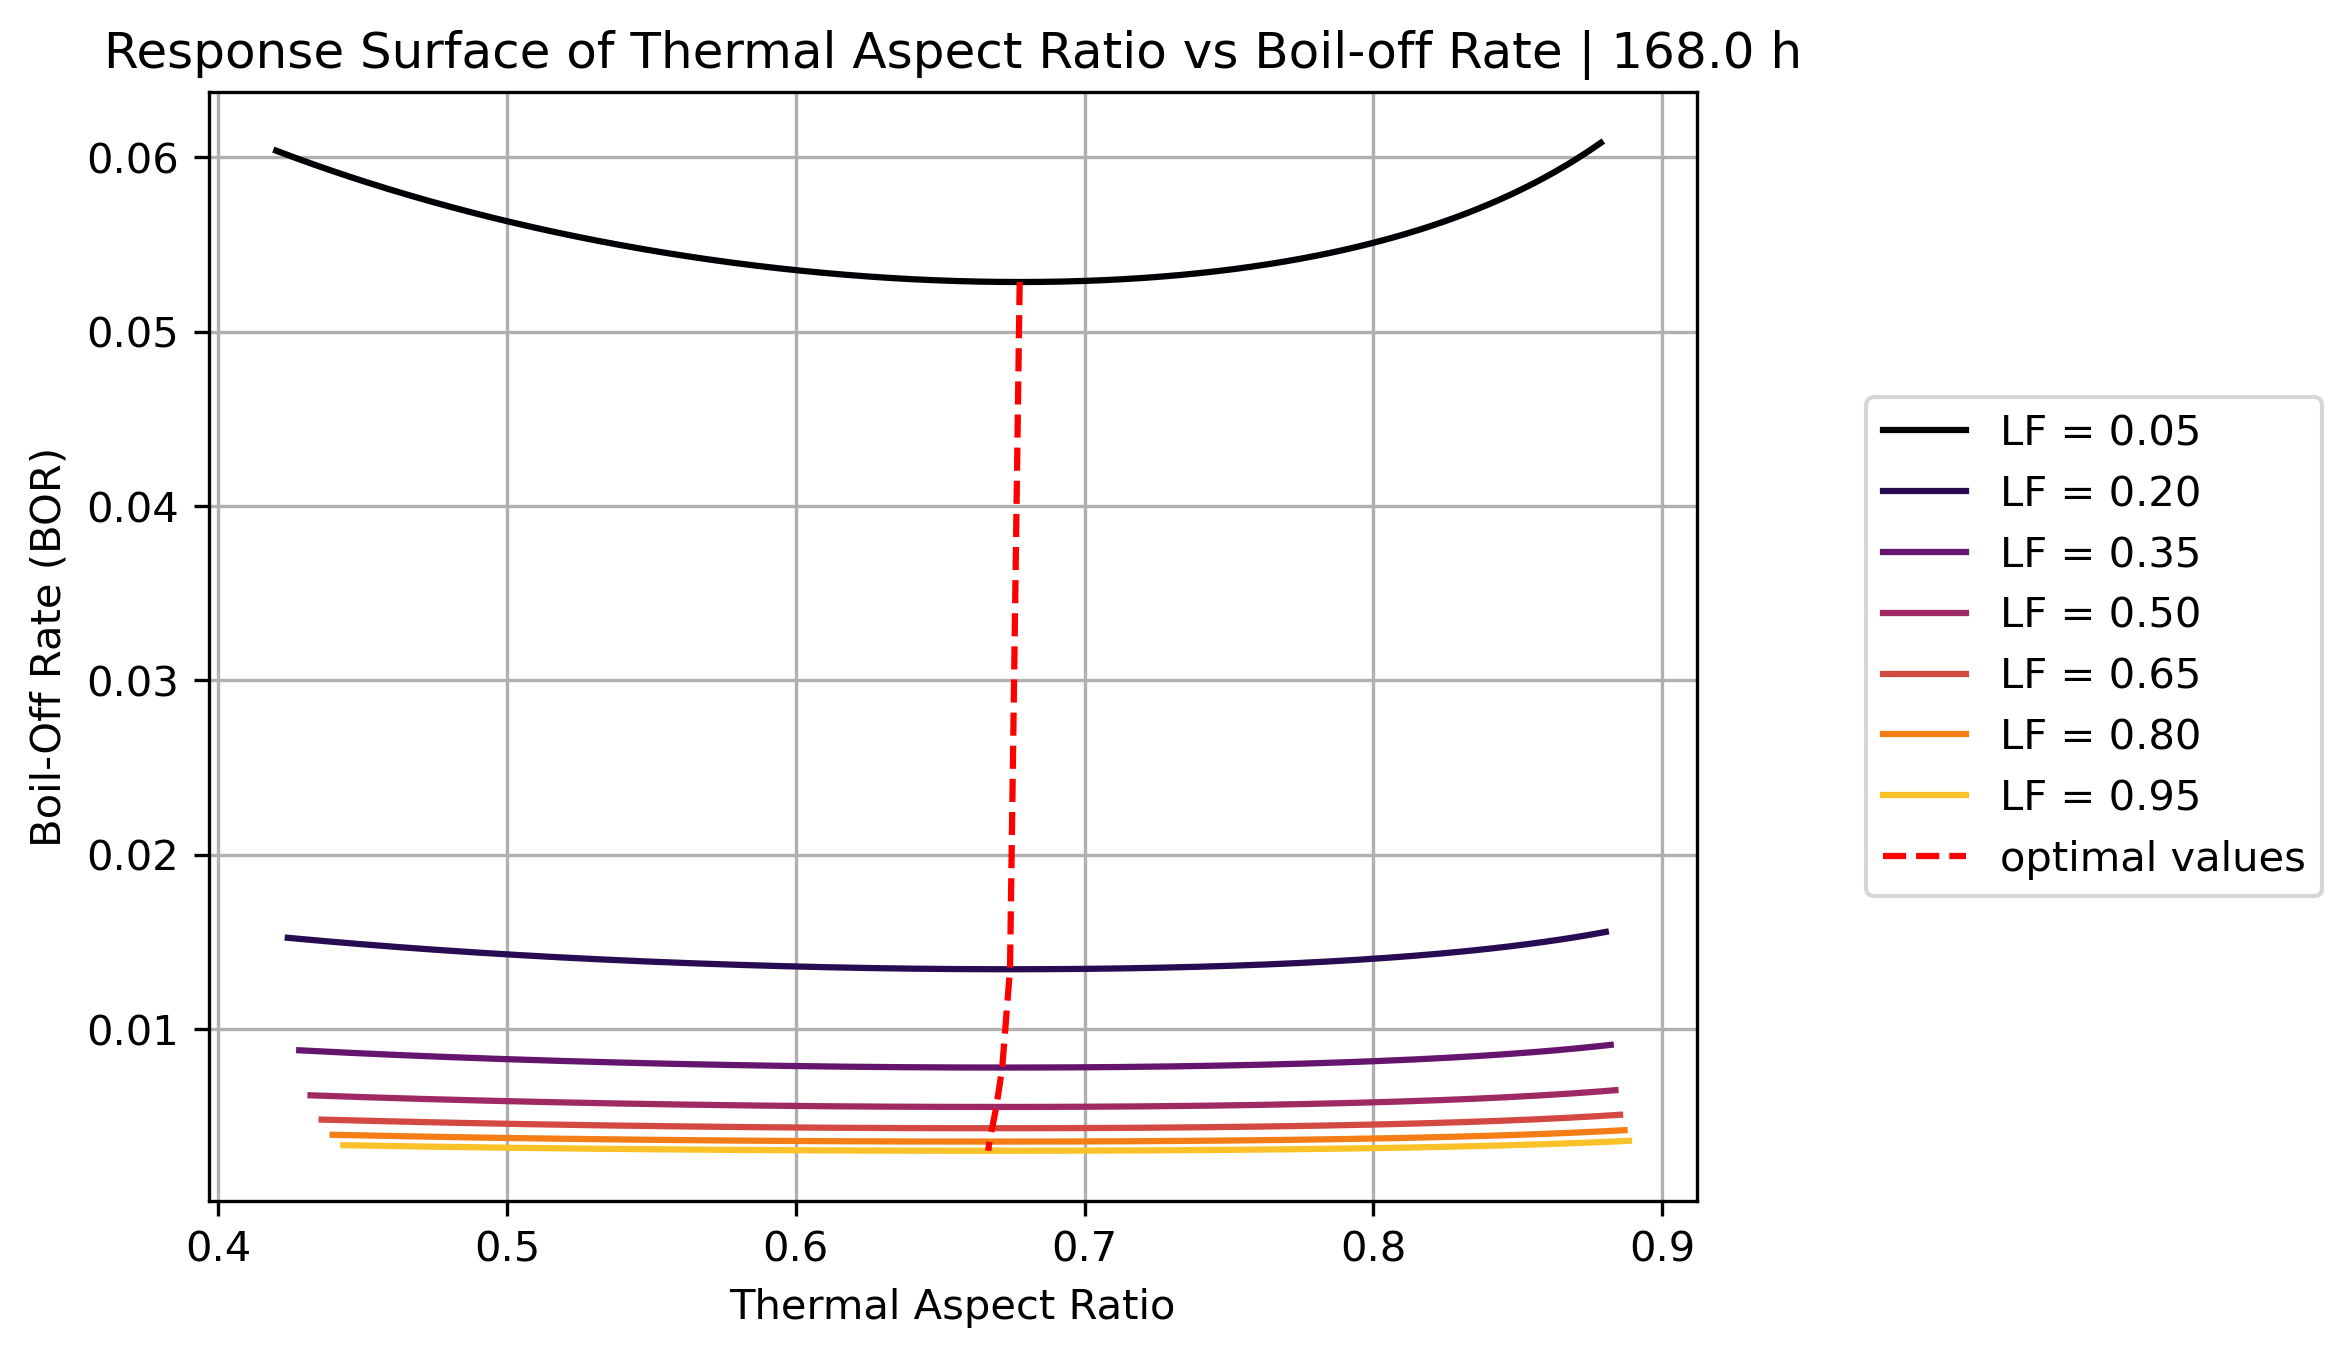

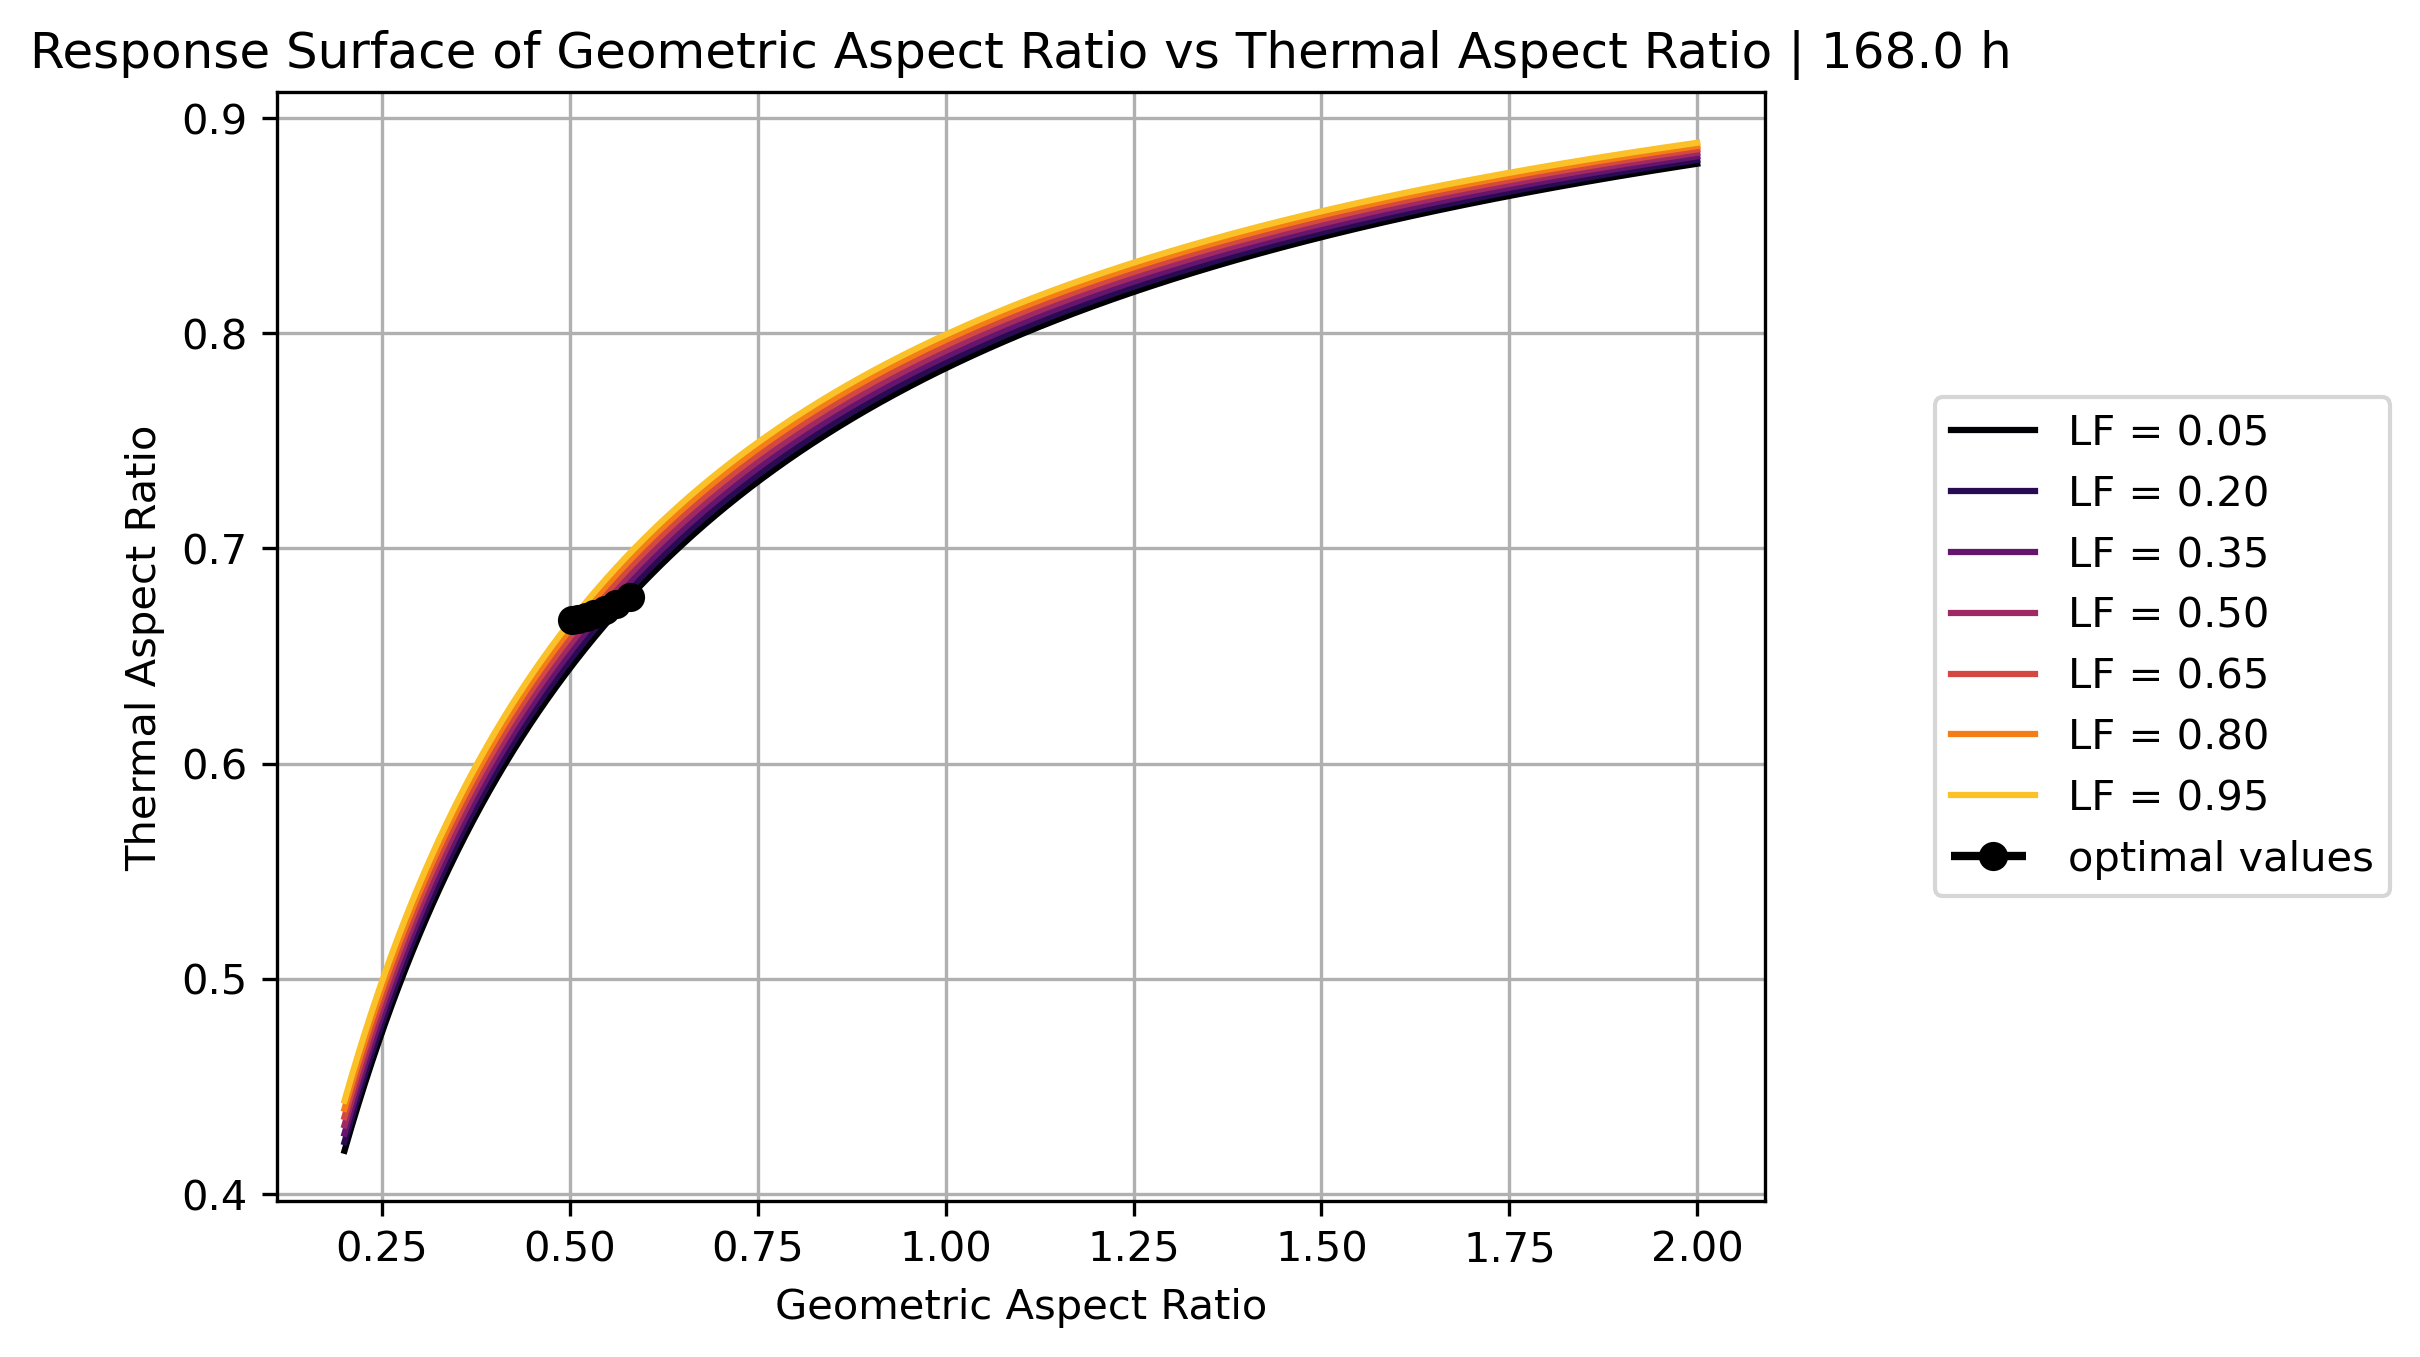

In [20]:
folder = "../Results/"
filename = folder + 'LAES_opti_168h_LFs.csv'
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.2, 2, 1000),
                                                               jnp.linspace(0.05, 0.95, 7),
                                                               168*3600,
                                                               save=True,
                                                               filename=filename)

#### Visualisation of results

#### Vapour temperature

In [13]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

TypeError: The solution object tank.sol does not exist.
Run tank.evaporate(t) to generate a solution
and thereafter run tank.plot_tv() again

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

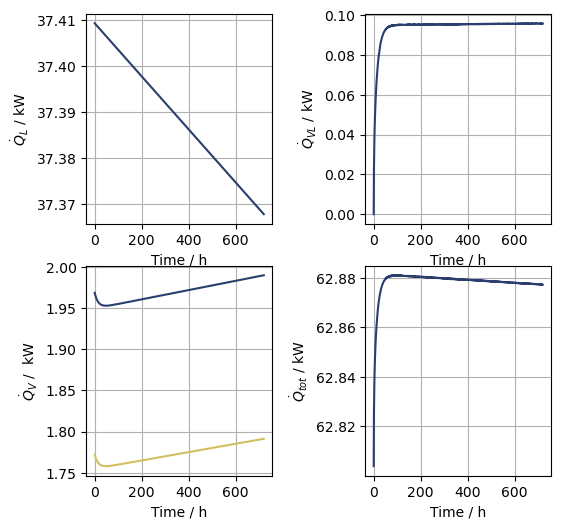

In [ ]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

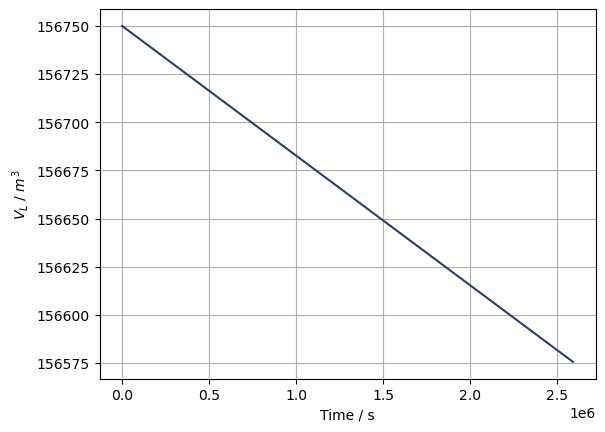

In [ ]:
large_tank.plot_V_L()

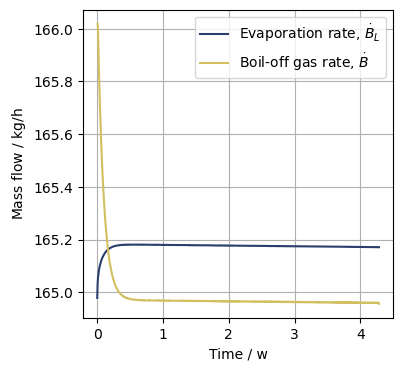

In [ ]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.